In [15]:
# ==========================================
# GOOGLE DRIVE + SAVE TRAINED MODEL
# ==========================================

from google.colab import drive
import os

# 1. Connect Google Drive
drive.mount('/content/drive')

# 2. Create project folders
project_path = "/content/drive/MyDrive/Plant_Health_Project"
models_path = project_path + "/models"

os.makedirs(project_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

print("✅ Google Drive connected!")
print("✅ Project folders ready!")

# 3. Check that the trained model exists
print("\nChecking trained model...")

try:
    print("Model found:", type(model))
except NameError:
    print("❌ 'model' is not currently available.")
    print("Do NOT restart the runtime. Your trained model needs to be loaded first.")

# 4. Save the trained model
if 'model' in globals():

    model_path = models_path + "/plant_model.keras"

    model.save(model_path)

    print("\n✅ MODEL SAVED SUCCESSFULLY!")
    print("Location:", model_path)

    # 5. Verify the saved file
    if os.path.exists(model_path):
        file_size = os.path.getsize(model_path) / (1024 * 1024)

        print("✅ File verified!")
        print("Model size:", round(file_size, 2), "MB")

else:
    print("\n⚠️ Model was not saved because 'model' is not available.")

Mounted at /content/drive
✅ Google Drive connected!
✅ Project folders ready!

Checking trained model...
Model found: <class 'keras.src.models.sequential.Sequential'>

✅ MODEL SAVED SUCCESSFULLY!
Location: /content/drive/MyDrive/Plant_Health_Project/models/plant_model.keras
✅ File verified!
Model size: 11.07 MB


In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

zip_path = "archive.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

print(os.listdir("/content/tomato_dataset"))

['new plant diseases dataset(augmented)', 'New Plant Diseases Dataset(Augmented)']


In [4]:
import os

base_path = "/content/tomato_dataset"

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    print("\n📁", folder)
    print(os.listdir(folder_path))


📁 new plant diseases dataset(augmented)
['New Plant Diseases Dataset(Augmented)']

📁 New Plant Diseases Dataset(Augmented)
['valid', 'train']


In [5]:
import os

train_path = "/content/tomato_dataset/New Plant Diseases Dataset(Augmented)/train"

print("Training classes:")
for folder in os.listdir(train_path):
    print(folder)

Training classes:
Tomato___healthy
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Leaf_Mold
Tomato___Target_Spot
Tomato___Bacterial_spot
Tomato___Tomato_mosaic_virus
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Tomato___Late_blight


In [6]:
import os

train_path = "/content/tomato_dataset/New Plant Diseases Dataset(Augmented)/train"
valid_path = "/content/tomato_dataset/New Plant Diseases Dataset(Augmented)/valid"

print("TRAINING DATA")
print("-" * 40)

for folder in sorted(os.listdir(train_path)):
    folder_path = os.path.join(train_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(folder, ":", count)

print("\nVALIDATION DATA")
print("-" * 40)

for folder in sorted(os.listdir(valid_path)):
    folder_path = os.path.join(valid_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(folder, ":", count)

TRAINING DATA
----------------------------------------
Tomato___Bacterial_spot : 1702
Tomato___Early_blight : 1920
Tomato___Late_blight : 1851
Tomato___Leaf_Mold : 1882
Tomato___Septoria_leaf_spot : 1745
Tomato___Spider_mites Two-spotted_spider_mite : 1741
Tomato___Target_Spot : 1827
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1961
Tomato___Tomato_mosaic_virus : 1790
Tomato___healthy : 1926

VALIDATION DATA
----------------------------------------
Tomato___Bacterial_spot : 425
Tomato___Early_blight : 480
Tomato___Late_blight : 463
Tomato___Leaf_Mold : 470
Tomato___Septoria_leaf_spot : 436
Tomato___Spider_mites Two-spotted_spider_mite : 435
Tomato___Target_Spot : 457
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 490
Tomato___Tomato_mosaic_virus : 448
Tomato___healthy : 481


In [7]:
import tensorflow as tf

train_path = "/content/tomato_dataset/New Plant Diseases Dataset(Augmented)/train"
valid_path = "/content/tomato_dataset/New Plant Diseases Dataset(Augmented)/valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:")
print(train_dataset.class_names)

Found 18345 files belonging to 10 classes.
Found 4585 files belonging to 10 classes.
Classes:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [8]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Preprocess training images
train_dataset = train_dataset.map(
    lambda images, labels: (preprocess_input(images), labels)
)

# Preprocess validation images
valid_dataset = valid_dataset.map(
    lambda images, labels: (preprocess_input(images), labels)
)

print("Images are ready for MobileNetV2!")

Images are ready for MobileNetV2!


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("Pretrained MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Pretrained MobileNetV2 loaded successfully!


In [10]:
base_model.trainable = False

print("MobileNetV2 base model frozen.")
print("Number of layers:", len(base_model.layers))

MobileNetV2 base model frozen.
Number of layers: 154


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

print("Tomato classification model created!")

Tomato classification model created!


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
valid_dataset = valid_dataset.prefetch(AUTOTUNE)

print("Dataset optimization completed!")

Dataset optimization completed!


In [14]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)

Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 926s 2s/step - accuracy: 0.7766 - loss: 0.6524 - val_accuracy: 0.8914 - val_loss: 0.3410
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.8807 - loss: 0.3504 - val_accuracy: 0.8979 - val_loss: 0.3054
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.9062 - loss: 0.2757 - val_accuracy: 0.9123 - val_loss: 0.2586
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 947s 2s/step - accuracy: 0.9165 - loss: 0.2395 - val_accuracy: 0.9206 - val_loss: 0.2386
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 981s 2s/step - accuracy: 0.9333 - loss: 0.1945 - val_accuracy: 0.9189 - val_loss: 0.2354
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9394 - loss: 0.1726 - val_accuracy: 0.9202 - val_loss: 0.2245
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.9456 - loss: 0.1565 - val_accuracy: 0.9328 - val_loss: 0.2011
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 946s 2s/step - accuracy: 0.9503 - loss: 0.1396 - val_acc

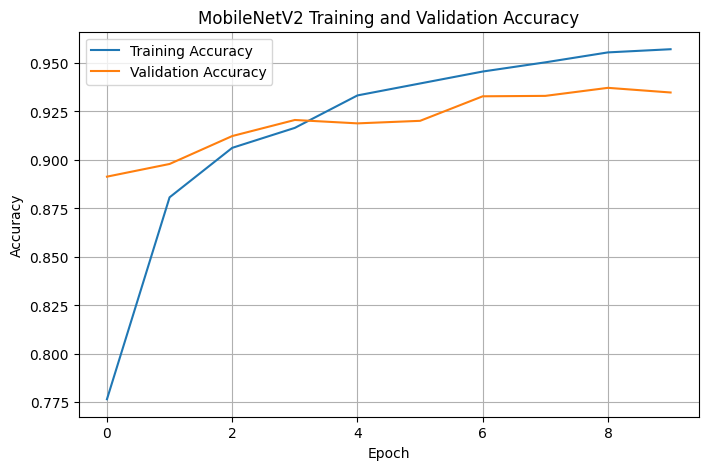

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

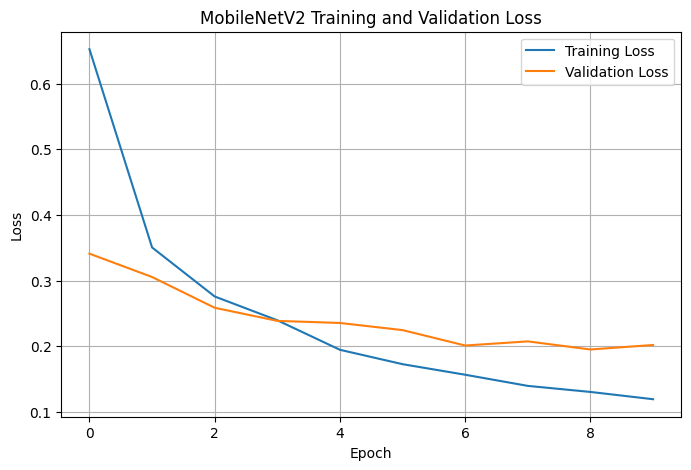

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [20]:
from google.colab import files

uploaded = files.upload()

print("Test image uploaded successfully!")

Saving tomato yellowing.png to tomato yellowing.png
Test image uploaded successfully!


In [21]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# Class names in the same order used during training
class_names = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Load image
image = load_img("tomato yellowing.png", target_size=(224, 224))

# Convert to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# MobileNetV2 preprocessing
image_array = preprocess_input(image_array)

# Prediction
prediction = model.predict(image_array)

# Find highest probability class
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence: 50.87 %


In [22]:
# Get probabilities for all 10 classes
probabilities = prediction[0]

# Get indices of top 3 predictions
top_3_indices = np.argsort(probabilities)[-3:][::-1]

print("Top 3 predictions:\n")

for i in top_3_indices:
    print(
        class_names[i],
        "->",
        round(probabilities[i] * 100, 2),
        "%"
    )

Top 3 predictions:

Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 50.87 %
Tomato___Late_blight -> 39.94 %
Tomato___Septoria_leaf_spot -> 4.98 %


In [23]:
from google.colab import files

uploaded = files.upload()

print("Images uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving Screenshot 2026-10-03 183728.png to Screenshot 2026-10-03 183728.png
Saving Screenshot 2026-10-03 183655.png to Screenshot 2026-10-03 183655.png
Saving Screenshot 2026-10-03 183632.png to Screenshot 2026-10-03 183632.png
Images uploaded:
Screenshot 2026-10-03 183728.png
Screenshot 2026-10-03 183655.png
Screenshot 2026-10-03 183632.png


In [24]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

image_files = [
    "Screenshot 2026-10-03 183728.png",
    "Screenshot 2026-10-03 183655.png",
    "Screenshot 2026-10-03 183632.png"
]

for filename in image_files:

    image = load_img(filename, target_size=(224, 224))
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)
    image_array = preprocess_input(image_array)

    prediction = model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    print("\nImage:", filename)
    print("Prediction:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")


Image: Screenshot 2026-10-03 183728.png
Prediction: Tomato___Early_blight
Confidence: 100.0 %

Image: Screenshot 2026-10-03 183655.png
Prediction: Tomato___Early_blight
Confidence: 99.97 %

Image: Screenshot 2026-10-03 183632.png
Prediction: Tomato___Late_blight
Confidence: 99.93 %


In [34]:
def get_health_status(prediction, class_names):

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index]

    if predicted_class == "Tomato___healthy":
        status = "HEALTHY"
    else:
        status = "UNHEALTHY"

    return status, predicted_class, confidence

print("Healthy/Unhealthy classification ready!")

Healthy/Unhealthy classification ready!


In [44]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Class names used during training
class_names = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Select your test image
image_path = "tomato yellowing.png"

# Load image
image = load_img(image_path, target_size=(224, 224))

# Convert image to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# MobileNetV2 preprocessing
image_array = preprocess_input(image_array)

# Predict
prediction = model.predict(image_array, verbose=0)

# Find predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]

# Convert to HEALTHY / UNHEALTHY
if predicted_class == "Tomato___healthy":
    health_status = "HEALTHY"
else:
    health_status = "UNHEALTHY"

confidence = prediction[0][predicted_index] * 100

print("================================")
print("      PLANT HEALTH RESULT")
print("================================")
print("Status     :", health_status)
print("AI Class   :", predicted_class)
print("Confidence :", round(confidence, 2), "%")

      PLANT HEALTH RESULT
Status     : UNHEALTHY
AI Class   : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence : 50.87 %
